## Директория 

### для файлов .fox:

In [539]:
fox_dir = "C:/Users/palo4/Desktop/MEPHI/Master/HNP/2026"

### для .dat файлов трекинга:

In [540]:
dat_dir = "C:/Users/palo4/Desktop/MEPHI/Master/HNP/2026/tracking data"

### Для изображений

In [555]:
img_dir = "C:/Users/palo4/Desktop/MEPHI/Master/HNP/2026/img"

## Поэлементный орибтальный и спиновый трекинг

In [541]:
import math
def get_tracking(v, s, spi, beta): 
    tracking_code = f"""
    INCLUDE '{v[0]}';
    PROCEDURE RUN; VARIABLE WHERE 100; VARIABLE MAPPARAMS 1 6;  VARIABLE MAPARR 1000 6 666; VARIABLE SPNRARR 1000 3 3 666; VARIABLE SGx1 1; VARIABLE SGy1 1; VARIABLE SGx2 1; VARIABLE SGy2 1; VARIABLE EB1 1; VARIABLE GAMMA 1; VARIABLE NUM_ELE 1; VARIABLE MRKR 50;
    
      OV 3 3 0;
      DAEPS 1E-12;
    
      GAMMA := {v[2]};
      NUM_ELE := {v[3]};
      
      SET_FOR_{v[1]} GAMMA;
      EB1 := {v[4]};
    
     SGx1 :=  {s[0]}; SGy1  := {s[1]}; SGx2 := {s[2]}; SGy2  := {s[3]};
    
      LATTICE SGx1 SGy1 SGx2 SGy2 EB1 1 MAPARR SPNRARR;
    
    SR 0 0 0 0 0 0 0 0 1; SSR {math.sin(spi)} 0 {math.cos(spi)};
    SR 1e-3 0 0 0 0 0 0 0 1; SSR {math.sin(spi)} 0 {math.cos(spi)};
    SR 1.5e-3 0 0 0 0 0 0 0 1; SSR {math.sin(spi)} 0 {math.cos(spi)};
    SR 2e-3 0 0 0 0 0 0 0 1; SSR {math.sin(spi)} 0 {math.cos(spi)};
    SR 2.5e-3 0 0 0 0 0 0 0 1; SSR {math.sin(spi)} 0 {math.cos(spi)};

    SR 3e-3 0 0 0 0 0 0 0 1; SSR {math.sin(spi)} 0 {math.cos(spi)};
    SR 3.5e-3 0 0 0 0 0 0 0 1; SSR {math.sin(spi)} 0 {math.cos(spi)};
    SR 4e-3 0 0 0 0 0 0 0 1; SSR {math.sin(spi)} 0 {math.cos(spi)};
    SR 4.5e-3 0 0 0 0 0 0 0 1; SSR {math.sin(spi)} 0 {math.cos(spi)};
    SR 0 0 0 0 0 1e-3 0 0 1; SSR {math.sin(spi)} 0 {math.cos(spi)};
    
      OPENF 924 '{dat_dir}/{v[5]}_{s[4]}_{spi}_{beta[0],beta[1]}_el-by-el.dat' 'REPLACE';
    OPENF 925 '{dat_dir}/{v[5]}_{s[4]}_{spi}_{beta[0],beta[1]}_el-by-el_spin.dat' 'REPLACE';
          TREL MAPARR SPNRARR 1 NUM_ELE 1 924 925;
      CLOSEF 924; 
    CLOSEF 925; 
    
    ENDPROCEDURE;
    
    RUN; END;
    """
    with open(f"{fox_dir}/track.fox", "w") as f:
        f.write(tracking_code)
    return ([f"{dat_dir}/{v[5]}_{s[4]}_{spi}_{beta[0],beta[1]}_el-by-el.dat", f"{dat_dir}/{v[5]}_{s[4]}_{spi}_{beta[0],beta[1]}_el-by-el_spin.dat"], v[5], s[4], spi, beta[0], beta[1])

## Выбор системы

In [542]:
""" ЭЛЕКТРОСТАТИЧЕСКАЯ СТРУКТУРА"""
"""
name = "electrostatic_maps"
particle = "protons"
gamma = 1.24810736
num_ele = 540
eb1 = 112.464392
mrkr = "ELECTROSTATIC"
"""
""" МАГНИТНАЯ СТРУКТУРА """

name = "magnetic_2p_maps"
particle = "deuterons"
gamma = 1.143914
num_ele = 100
eb1 = 0
mrkr = "MAGNETIC_2P"

variables = [name, particle, gamma, num_ele, eb1, mrkr]

## Настройка секступолей

In [543]:
""" БЕЗ СЕКСТУПОЛЕЙ """
"""
mode = "NC"
SGx1 = 0
SGy1 = 0
SGx2 = 0
SGy2 = 0
"""

""" chrom_x,chrom_y, ETA = 0 in electrostatic ring"""
"""
mode = "BC" 
SGx1 = 7.112772e-04 
SGx2 = 3.005243e-03
SGy1 = -2.897679e-03
SGy2 = 0
"""

""" spin coherence in electrostatic ring """
"""
mode = "SC" 
SGx1 = 8.493069e-05
SGx2 = -8.472331e-04 
SGy1 = 3.070885e-04  
SGy2 = 0
"""

""" chrom_x chrom_y, ETA = 0 in magnetic_2p ring"""

mode = "BC" 
SGx1 = 1.044306e-03 
SGx2 = 4.924066e-04
SGy1 = -1.510996e-03
SGy2 = 0


""" spin coherence in magnetic_2p  ring """
"""
mode = "SC" 
SGx1 = -7.197408e-04
SGx2 = 6.552895e-04
SGy1 = 2.105317e-03
SGy2 = 0
"""

sextupoles = [SGx1, SGy1, SGx2, SGy2, mode]

## Начальное отклонение спин-вектора от продольного направления (в градусах)

In [544]:
spin_initial = 0

## Значение бетатронного тюна

In [545]:
%run get_BT_and_chrom.ipynb

get_BT_and_chrom(variables, sextupoles, fox_dir)


In [546]:
beta_tune = [0.67, 0.37] 

## Формирование кода для трекинга

In [547]:
filename = get_tracking(variables, sextupoles, spin_initial, beta_tune)

## Запуск поэлементного трекинга

In [548]:
import subprocess

c = f"{fox_dir}/track.fox"
subprocess.Popen(f'start cmd /c cosy {c}', shell=True)

<Popen: returncode: None args: 'start cmd /c cosy C:/Users/palo4/Desktop/MEP...>

## Обработка данных трекинга

### График поворота спин вектора в элементах структуры

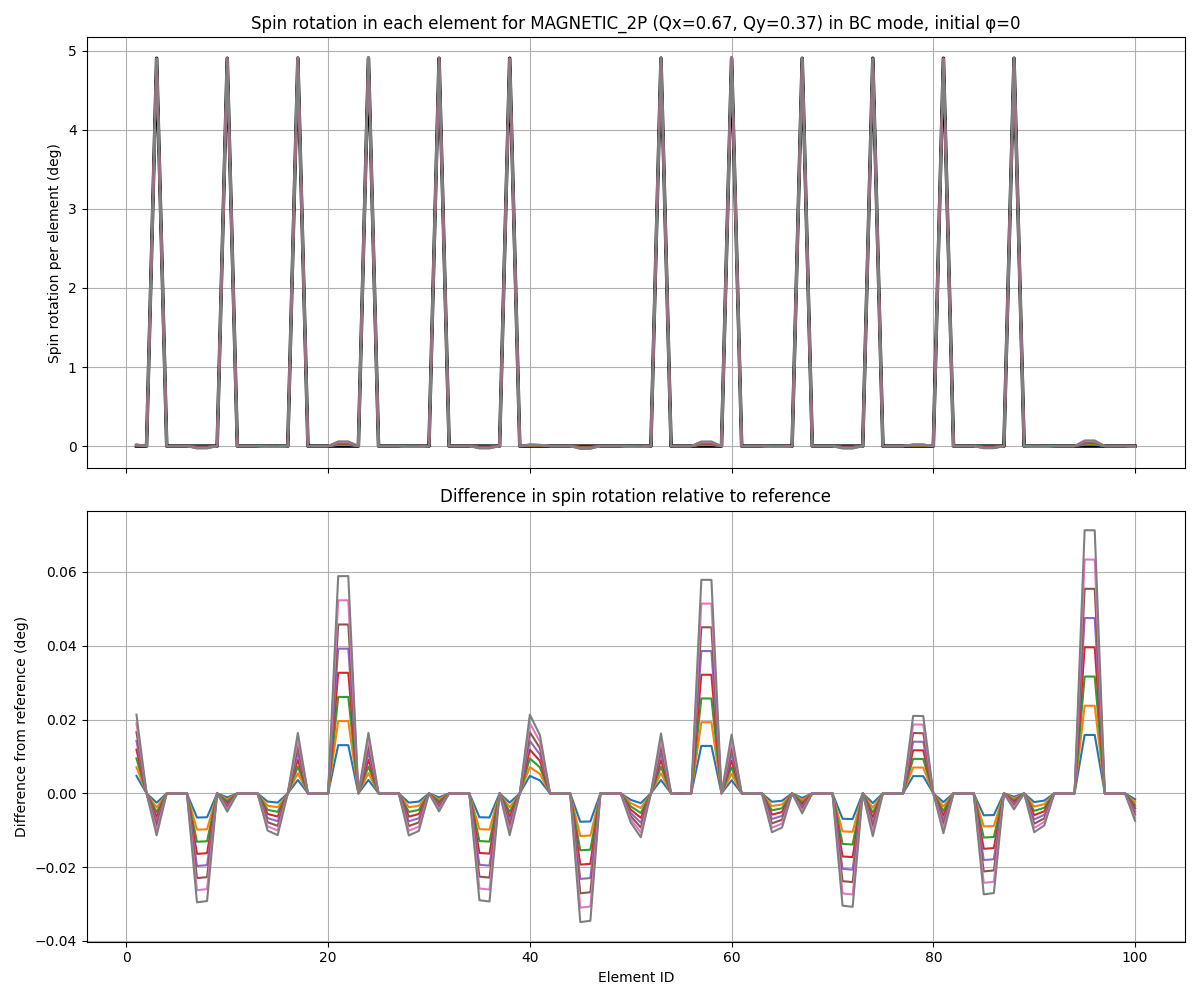

In [549]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Спиновый трекинг
# ==========================

names = ["iteration", "EID", "vector", "Sx", "Sy", "Sz"]

df_spin = pd.read_csv(
    filename[0][1],
    comment="#",
    sep=r"\s+",
    header=None,
    names=names
)

df_spin = df_spin.sort_values(
    by=["iteration", "EID", "vector"]
).reset_index(drop=True)

# ==========================
# Референсный луч
# ==========================

ref = df_spin[df_spin["vector"] == 1]

ref_angles = np.rad2deg(
    np.unwrap(
        np.arctan2(
            ref["Sx"].to_numpy(),
            ref["Sz"].to_numpy()
        )
    )
)

# Приращение в каждом элементе
ref_increment = np.diff(ref_angles)

# Приращению соответствует элемент, в который вошли
elements = ref["EID"].to_numpy()[1:]

# ==========================
# Построение графиков
# ==========================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Референс
ax1.plot(elements, ref_increment, "k", lw=2.5, label="Reference")

ignore = [0, 1, 10]

for vector in sorted(df_spin["vector"].unique()):

    if vector in ignore:
        continue

    antiref = df_spin[df_spin["vector"] == vector]

    assert np.array_equal(
        ref["EID"].to_numpy(),
        antiref["EID"].to_numpy()
    ), f"EID mismatch for vector {vector}"

    antiref_angles = np.rad2deg(
        np.unwrap(
            np.arctan2(
                antiref["Sx"].to_numpy(),
                antiref["Sz"].to_numpy()
            )
        )
    )

    antiref_increment = np.diff(antiref_angles)

    # Абсолютное приращение
    ax1.plot(elements, antiref_increment, label=f"Ray {vector}")

    # Отличие от референса
    delta_increment = antiref_increment - ref_increment
    ax2.plot(elements, delta_increment, label=f"Ray {vector}")

# ==========================
# Оформление
# ==========================

ax1.set_ylabel("Spin rotation per element (deg)")
ax1.set_title(
    f"Spin rotation in each element for {filename[1]} "
    f"(Qx={filename[4]}, Qy={filename[5]}) "
    f"in {filename[2]} mode, initial φ={filename[3]}"
)
ax1.grid(True)
#ax1.legend()

ax2.set_xlabel("Element ID")
ax2.set_ylabel("Difference from reference (deg)")
ax2.set_title("Difference in spin rotation relative to reference")
ax2.grid(True)
#ax2.legend()

plt.tight_layout()
plt.savefig(f"{img_dir}/{filename[1]_{filename[2]}_{filename[3]}_{filename[4]}_{filename[5]}}.png")  # сохраняется в папку plots
plt.show()

## Расчет вклада в поворот от элементов

In [550]:
import re
import pandas as pd
import numpy as np

# ==========================
# Чтение списка элементов
# ==========================

records = []

with open("electrostatic_maps.fox", encoding="utf-8") as f:
    for line in f:
        m = re.search(r"\{([^}]+)\}\s+SMAPS\s+(\d+)", line)
        if m:
            records.append({
                "EID": int(m.group(2)),
                "Element": m.group(1)
            })

df_elements = pd.DataFrame(records)

# ==========================
# Выбор луча
# ==========================

vector = 3        # <-- здесь выбирается номер луча

ray = (
    df_spin[df_spin["vector"] == vector]
    .sort_values("EID")
)

# ==========================
# Угол поворота спина
# ==========================

angles = np.rad2deg(
    np.unwrap(
        np.arctan2(
            ray["Sx"].to_numpy(),
            ray["Sz"].to_numpy()
        )
    )
)

# Приращение угла в каждом элементе
dphi = np.diff(angles)

spin = pd.DataFrame({
    "EID": ray["EID"].to_numpy()[1:],
    "dphi": dphi
})

# ==========================
# Соединяем с названиями элементов
# ==========================

spin = spin.merge(df_elements, on="EID", how="inner")

# ==========================
# Сводная таблица
# ==========================

summary = (
    spin
    .groupby("Element")
    .agg(
        Count=("Element", "size"),
        Total_rotation=("dphi", "sum"),
        Total_abs_rotation=("dphi", lambda x: np.abs(x).sum()),
        Mean_abs_rotation=("dphi", lambda x: np.abs(x).mean()),
        Max_abs_rotation=("dphi", lambda x: np.abs(x).max())
    )
    .sort_values("Total_abs_rotation", ascending=False)
)

print(f"\nRay {vector}\n")
print(summary)


Ray 3

         Count  Total_rotation  Total_abs_rotation  Mean_abs_rotation  \
Element                                                                 
OD2         22     19.69501819         19.72848306         0.89674923   
OD1         22     19.59481783         19.66705892         0.89395722   
Lf          10      9.77844146          9.83890223         0.98389022   
SDP          6      4.94202258          4.94202258         0.82367043   
BPM         11      4.90269391          4.92238417         0.44748947   
R1          10      0.01414890          0.04384131         0.00438413   
Ld          10     -0.02678405          0.02678405         0.00267840   
Lds          1      0.00710453          0.00710453         0.00710453   
Lfs          2     -0.00243690          0.00243690         0.00121845   
SFP          5      0.00000565          0.00000565         0.00000113   
OR1          1     -0.00000514          0.00000514         0.00000514   

         Max_abs_rotation  
Element       

### Таблица с данными

In [551]:
names = ["iteration", "EID", "vector", "x", "a", "y", "b", "t", "d"]

df_orb = pd.read_csv(
    filename[0][0],
    comment="#",
    sep=r"\s+",
    header=None,
    names=names
)

df_orb = df_orb.sort_values(
    by=["iteration", "EID", "vector"]
).reset_index(drop=True)

# ==========================
# начальные координаты
# ==========================

initcond = df_orb[df_orb["EID"] == 0].groupby("vector")[["x", "y", "d"]].first()
initcond = initcond.rename(columns={"x": "x0", "y": "y0", "d": "d0"})

# ==========================
# спиновая часть
# ==========================

results = []

ref_increment = np.diff(ref_angles, prepend=0)

# референс
results.append({
    "Lattice": f"{filename[1]}",
    "Optimization": f"{filename[2]}",
    "Initial_spin_angle": f"{filename[3]}",
    "Qx": f"{float(filename[4])}",
    "Qy": f"{float(filename[5])}",
    "Ray": "Ref",
    "Spin_rotation_per_turn_(deg)": ref_increment.sum(),
    "Max_|dθ|_element": ref["EID"].iloc[np.argmax(np.abs(ref_increment))]
})

ignore = [0, 1]

for vector in sorted(df_spin["vector"].unique()):

    if vector in ignore:
        continue

    antiref = df_spin[df_spin["vector"] == vector]

    assert np.array_equal(
        ref["EID"].to_numpy(),
        antiref["EID"].to_numpy()
    ), f"EID mismatch for vector {vector}"

    antiref_angles = np.degrees(np.arcsin(antiref["Sx"].to_numpy()))
    antiref_increment = np.diff(antiref_angles, prepend=0)

    results.append({
        "Lattice": f"{filename[1]}",
        "Optimization": f"{filename[2]}",
        "Initial_spin_angle": f"{filename[3]}",
        "Qx": f"{float(filename[4])}",
        "Qy": f"{float(filename[5])}",
        "Ray": int(vector),
        "Spin_rotation_per_turn_(deg)": antiref_increment.sum(),
        "Max_|dθ|_element": antiref["EID"].iloc[np.argmax(np.abs(antiref_increment))]
    })

# ==========================
# таблица + координаты
# ==========================

results = pd.DataFrame(results)

# приводим Ray к ключу merge
results["vector"] = results["Ray"].replace("Reference", 1)

results = results.merge(initcond, on="vector", how="left")

df = results.copy()

# переводим всё в строки (для расчёта ширины)
df_str = df.astype(str)

# считаем ширину каждого столбца
col_widths = {
    col: max(len(col), df_str[col].map(len).max())
    for col in df_str.columns
}

# форматированная печать
def fmt_row(row):
    return "  ".join(
        str(row[col]).rjust(col_widths[col])
        for col in df_str.columns
    )

# header
header = "  ".join(
    col.rjust(col_widths[col]) for col in df_str.columns
)

print(header)
print("-" * len(header))

for _, row in df_str.iterrows():
    print(fmt_row(row))

    Lattice  Optimization  Initial_spin_angle    Qx    Qy  Ray  Spin_rotation_per_turn_(deg)  Max_|dθ|_element  vector      x0   y0     d0
------------------------------------------------------------------------------------------------------------------------------------------
MAGNETIC_2P            BC                   0  0.67  0.37  Ref             58.88333765353025                60     Ref     nan  nan    nan
MAGNETIC_2P            BC                   0  0.67  0.37    2             58.89780548892162                24       2   0.001  0.0    0.0
MAGNETIC_2P            BC                   0  0.67  0.37    3            58.905026916621985                24       3  0.0015  0.0    0.0
MAGNETIC_2P            BC                   0  0.67  0.37    4            58.912238757447064                24       4   0.002  0.0    0.0
MAGNETIC_2P            BC                   0  0.67  0.37    5            58.919441005506094                17       5  0.0025  0.0    0.0
MAGNETIC_2P            BC  

## Сохранение данных в файл

#### Обработанные данные:

In [552]:
output_dir = "C:/Users/palo4/Desktop/MEPHI/Master/HNP/2026/output"

In [554]:
output_file = f"{output_dir}/results_for_{filename[1]}_{filename[2]}_{filename[3]}_{filename[4]}_{filename[5]}.dat"

df = results.copy()
df_str = df.astype(str)

col_widths = {
    col: max(len(col), df_str[col].map(len).max())
    for col in df_str.columns
}

def fmt_row(row):
    return "  ".join(
        str(row[col]).rjust(col_widths[col])
        for col in df_str.columns
    )

header = "  ".join(
    col.rjust(col_widths[col]) for col in df_str.columns
)

with open(output_file, "w", encoding="utf-8") as f:
    f.write(header + "\n")
    f.write("-" * len(header) + "\n")

    for _, row in df_str.iterrows():
        f.write(fmt_row(row) + "\n")


    # ============================================
    # Вклад каждого типа элемента для всех лучей
    # ============================================

    f.write("\n\n")
    f.write("=" * 80 + "\n")
    f.write("Contribution of element types to spin rotation\n")
    f.write("=" * 80 + "\n")

    ignore = [0]

    for vector in sorted(df_spin["vector"].unique()):

        if vector in ignore:
            continue

        ray = (
            df_spin[df_spin["vector"] == vector]
            .sort_values("EID")
        )

        angles = np.rad2deg(
            np.unwrap(
                np.arctan2(
                    ray["Sx"].to_numpy(),
                    ray["Sz"].to_numpy()
                )
            )
        )

        dphi = np.diff(angles)

        spin = pd.DataFrame({
            "EID": ray["EID"].to_numpy()[1:],
            "dphi": dphi
        })

        spin = spin.merge(df_elements, on="EID", how="inner")

        summary = (
            spin
            .groupby("Element")
            .agg(
                Count=("Element", "size"),
                Total_rotation=("dphi", "sum"),
                Total_abs_rotation=("dphi", lambda x: np.abs(x).sum()),
                Mean_abs_rotation=("dphi", lambda x: np.abs(x).mean()),
                Max_abs_rotation=("dphi", lambda x: np.abs(x).max())
            )
            .sort_values("Total_abs_rotation", ascending=False)
            .reset_index()
        )

        f.write(f"\n\nRay {vector}\n")

        summary_str = summary.astype(str)

        col_widths = {
            col: max(len(col), summary_str[col].map(len).max())
            for col in summary_str.columns
        }

        header = "  ".join(
            col.rjust(col_widths[col])
            for col in summary_str.columns
        )

        f.write(header + "\n")
        f.write("-" * len(header) + "\n")

        for _, row in summary_str.iterrows():
            line = "  ".join(
                str(row[col]).rjust(col_widths[col])
                for col in summary_str.columns
            )
            f.write(line + "\n")